# Deployable RUL Regression

## Goal
Predict **remaining useful life (cycles)** for each engine so maintenance teams can:
- Schedule service at the right time — not too early (wasted life) and not too late (failure)
- Prioritise across the fleet: which engines are most urgent this week?

## Design choices
- **Regression, not classification**: a number ("~42 cycles left") is more actionable than a binary label
- **Asymmetric loss**: over-predicting RUL is penalised 3× more than under-predicting — safety bias
- **Multi-scale history**: raw sensors + baseline deviation + local trend + global slope + sensor ratios + **lag features at 1, 5, 10, 20, 30 cycles** — the model sees the full recent trajectory
- **Deployment simulation**: alarm fires when `predicted_RUL < TRIGGER`; walk each engine cycle-by-cycle and count how many true cycles remained when the alarm fired

In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

COLS = [
    'Unit Number', 'Time (Cycles)', 'Altitude', 'Mach Number', 'TRA',
    'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30',
    'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc',
    'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32'
]
SENSORS = COLS[5:]       # 21 sensor readings

TRIGGER  = 30            # alarm fires when predicted_RUL < TRIGGER
                         # also defines urgency: engines with true_rul < TRIGGER are at risk
RUL_CAP  = 125           # cap training RUL

BASELINE_N   = 10        # cycles to freeze healthy baseline
TREND_SMOOTH = 10        # rolling mean window before computing slope
TREND_WINDOW = 20        # diff window for local slope

LAG_PERIODS  = [1, 5, 10, 20, 30]   # previous time frames to include as features
MIN_CYCLES   = 30        # warmup: don't fire alarm until engine has been observed this many cycles

In [3]:
def load_training(filename):
    df = pd.read_csv(f'../Data/{filename}', sep=' ', header=None).iloc[:, :26]
    df.columns = COLS
    max_cycle = df.groupby('Unit Number')['Time (Cycles)'].max().rename('max_cycle')
    df = df.join(max_cycle, on='Unit Number')
    df['RUL'] = df['max_cycle'] - df['Time (Cycles)']
    return df

def load_nasa_test(filename, rul_file):
    df = pd.read_csv(f'../Data/{filename}', sep=' ', header=None).iloc[:, :26]
    df.columns = COLS
    rul_gt = pd.read_csv(f'../Data/{rul_file}', header=None, names=['true_rul'])
    rul_gt['Unit Number'] = rul_gt.index + 1
    last_cycle = df.groupby('Unit Number')['Time (Cycles)'].max().rename('last_cycle')
    df = df.join(last_cycle, on='Unit Number')
    df = df.join(rul_gt.set_index('Unit Number')['true_rul'], on='Unit Number')
    df['RUL'] = (df['last_cycle'] + df['true_rul']) - df['Time (Cycles)']
    return df

offset = 0; train_parts = []
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    d = load_training(f'train_{fd}.txt')
    d['Unit Number'] += offset; d['dataset'] = fd
    offset = d['Unit Number'].max(); train_parts.append(d)
df_all = pd.concat(train_parts, ignore_index=True)

offset = 0; nasa_parts = []
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    d = load_nasa_test(f'test_{fd}.txt', f'RUL_{fd}.txt')
    d['Unit Number'] += offset; d['dataset'] = fd
    offset = d['Unit Number'].max(); nasa_parts.append(d)
nasa_raw = pd.concat(nasa_parts, ignore_index=True)

print(f"Training : {df_all['Unit Number'].nunique():>4} engines | {len(df_all):>7,} rows")
print(f"NASA test: {nasa_raw['Unit Number'].nunique():>4} engines | {len(nasa_raw):>7,} rows")

Training :  709 engines | 160,359 rows
NASA test:  707 engines | 104,897 rows


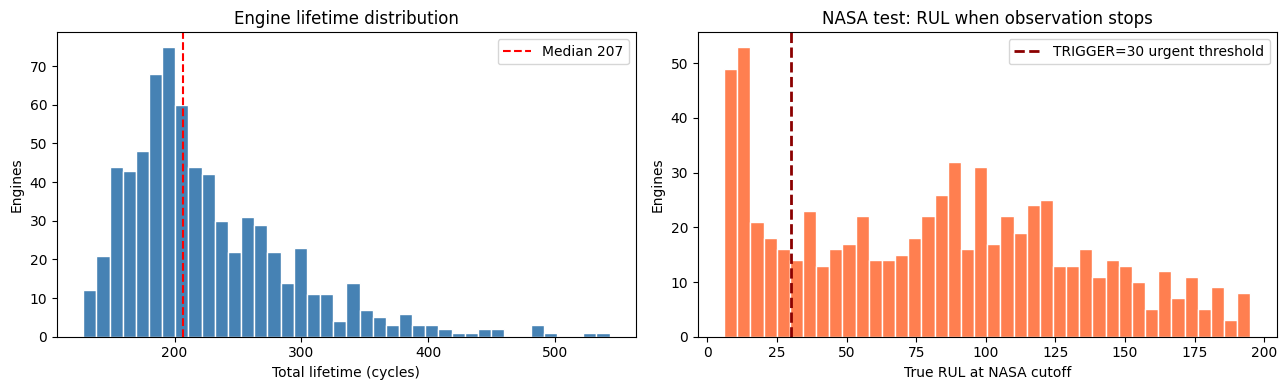

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
lifetimes = df_all.groupby('Unit Number')['max_cycle'].first()
axes[0].hist(lifetimes, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(lifetimes.median(), color='red', ls='--', lw=1.5, label=f'Median {int(lifetimes.median())}')
axes[0].set(xlabel='Total lifetime (cycles)', ylabel='Engines', title='Engine lifetime distribution'); axes[0].legend()

nasa_rul = nasa_raw.groupby('Unit Number')['true_rul'].first()
axes[1].hist(nasa_rul, bins=40, color='coral', edgecolor='white')
axes[1].axvline(TRIGGER, color='darkred', ls='--', lw=2, label=f'TRIGGER={TRIGGER} urgent threshold')
axes[1].set(xlabel='True RUL at NASA cutoff', ylabel='Engines', title='NASA test: RUL when observation stops'); axes[1].legend()
plt.tight_layout(); plt.show()

## Feature Engineering

### Leakage rules
At every timestep t, a feature may only use data from cycles 1 … t.  
No `max_cycle`, no `RUL`, no `shift(-n)`, no `groupby().transform()` on the full engine.  
`Time (Cycles)` is excluded — in a dataset with consistent engine lifetimes it acts as a direct proxy for RUL, which would be shortcut learning rather than sensor-based degradation modelling.

### Feature inventory

| Group | # features | What it captures |
|---|---|---|
| Raw sensors | 21 | Absolute physical readings |
| `_dev` | 21 | Drift from the engine's own early-life baseline |
| `_trend` | 21 | Rate of change over the last 20 cycles |
| `_hslope` | 21 | Average drift rate since cycle 1 |
| Ratios | 5 | Thermodynamic efficiency between paired sensors |
| `_lagN` | 21 × 5 = 105 | Raw readings N cycles ago |
| `_lagdiffA_B` | 21 × 4 = 84 | Change between consecutive lag windows — acceleration of degradation |
| **Total** | **278** | |

### Feature 1 — Raw sensor readings (`SENSORS`)

The 21 raw measurement channels. No transformation — physical readings as-is.  
**Leakage check**: cycle-t reading uses no future data. ✓

In [5]:
print(f"Sensors ({len(SENSORS)}): " + ", ".join(SENSORS))
assert 'RUL' not in SENSORS and 'max_cycle' not in SENSORS
print("Leakage check: SENSORS contains no RUL or max_cycle. ✓")

Sensors (21): T2, T24, T30, T50, P2, P15, P30, Nf, Nc, epr, Ps30, phi, NRf, NRc, BPR, farB, htBleed, Nf_dmd, PCNfR_dmd, W31, W32
Leakage check: SENSORS contains no RUL or max_cycle. ✓


### Feature 2 — Baseline deviation (`_dev`)

How far is the current reading from this engine's own early-life healthy state?

`dev[t] = sensor[t] − baseline`, where baseline = expanding mean frozen after `BASELINE_N` cycles.

Captures personalised drift — a sensor at 450 means nothing; the same sensor starting at 460 and drifting to 450 signals degradation.  
**Leakage check**: expanding mean uses only cycles 1…t; baseline frozen at cycle 10. ✓

In [6]:
DEV_COLS = [f'{s}_dev' for s in SENSORS]
for df in [df_all, nasa_raw]:
    parts = []
    for unit, eng in df.groupby('Unit Number'):
        eng = eng.sort_values('Time (Cycles)').copy()
        n = len(eng)
        cumean = eng[SENSORS].expanding(min_periods=1).mean()
        frozen = cumean.iloc[min(BASELINE_N - 1, n - 1)]
        new = {}
        for s in SENSORS:
            bl = np.where(np.arange(n) < BASELINE_N, cumean[s].values, frozen[s])
            new[f'{s}_dev'] = eng[s].values - bl
        parts.append(pd.DataFrame(new, index=eng.index))
    feat = pd.concat(parts)
    for col in DEV_COLS: df[col] = feat[col]
print(f"Added {len(DEV_COLS)} deviation features")

Added 21 deviation features


### Feature 3 — Local trend (`_trend`)

How fast is the sensor moving *right now*?

`trend[t] = (smooth[t] − smooth[t−20]) / 20`, where smooth is a 10-cycle rolling mean.

Complements `_dev`: an engine within normal bounds but accelerating rapidly towards failure shows up here.  
**Leakage check**: rolling mean and diff are backward-looking; `fillna(0)` is neutral. ✓

In [7]:
TREND_COLS = [f'{s}_trend' for s in SENSORS]
for df in [df_all, nasa_raw]:
    parts = []
    for unit, eng in df.groupby('Unit Number'):
        eng = eng.sort_values('Time (Cycles)').copy()
        new = {f'{s}_trend': eng[s].rolling(TREND_SMOOTH, min_periods=1).mean()
                                    .diff(TREND_WINDOW).fillna(0).values / TREND_WINDOW
               for s in SENSORS}
        parts.append(pd.DataFrame(new, index=eng.index))
    feat = pd.concat(parts)
    for col in TREND_COLS: df[col] = feat[col]
print(f"Added {len(TREND_COLS)} trend features")

Added 21 trend features


### Feature 4 — Global history slope (`_hslope`)

The average drift rate over the engine's *entire* observed life.

`hslope[t] = (expanding_mean[t] − sensor[cycle_1]) / t`

- `_dev` tells you *how far* the sensor has drifted  
- `_trend` tells you *how fast* it's moving now  
- `_hslope` tells you *how fast it has been drifting on average* since new

Two engines with the same `_dev` but different ages have very different urgency; `_hslope` captures that.  
**Leakage check**: expanding mean uses only cycles 1…t; `sensor[cycle_1]` is the observed first reading. ✓

In [8]:
HSLOPE_COLS = [f'{s}_hslope' for s in SENSORS]
for df in [df_all, nasa_raw]:
    parts = []
    for unit, eng in df.groupby('Unit Number'):
        eng = eng.sort_values('Time (Cycles)').copy()
        new = {}
        for s in SENSORS:
            hist_mean = eng[s].expanding(min_periods=1).mean()
            new[f'{s}_hslope'] = (hist_mean.values - eng[s].iloc[0]) / np.maximum(eng['Time (Cycles)'].values, 1)
        parts.append(pd.DataFrame(new, index=eng.index))
    feat = pd.concat(parts)
    for col in HSLOPE_COLS: df[col] = feat[col]
print(f"Added {len(HSLOPE_COLS)} history-slope features")

Added 21 history-slope features


### Feature 5 — Sensor ratios

Ratios between physically related sensors that are more stable across operating conditions than absolute readings.

| Sensor | Type | Location |
|---|---|---|
| T24 | Total temperature | LPC outlet |
| T30 | Total temperature | HPC outlet |
| T50 | Total temperature | LPT outlet |
| P2  | Total pressure    | Fan inlet |
| P15 | Total pressure    | Bypass duct |
| P30 | Total pressure    | HPC outlet |
| NRf | Corrected speed   | Fan |
| NRc | Corrected speed   | Core |

| Ratio | Meaning |
|---|---|
| T30 / T24 | HPC temperature ratio — rises as compressor efficiency drops |
| T50 / T30 | Turbine temperature ratio — rises as turbine degrades |
| P30 / P2  | Overall pressure ratio — falls as compressor wears |
| P30 / P15 | HPC-to-bypass pressure ratio |
| NRf / NRc | Fan-to-core speed balance — imbalance signals mechanical wear |

**Leakage check**: ratios use only the current cycle's readings. ✓

In [9]:
RATIO_PAIRS = [('T30','T24'),('T50','T30'),('P30','P2'),('P30','P15'),('NRf','NRc')]
RATIO_COLS  = [f'{n}_over_{d}' for n, d in RATIO_PAIRS]
for df in [df_all, nasa_raw]:
    for num, den in RATIO_PAIRS:
        df[f'{num}_over_{den}'] = df[num] / df[den].clip(lower=1e-6)
print(f"Added {len(RATIO_COLS)} ratio features: " + ", ".join(RATIO_COLS))

Added 5 ratio features: T30_over_T24, T50_over_T30, P30_over_P2, P30_over_P15, NRf_over_NRc


### Feature 6 — Previous time frames (`_lagN`)

The model currently knows what the sensor reads *at cycle t*. Lag features give it access to the actual readings at *t−1, t−5, t−10, t−20, t−30* cycles ago — the recent trajectory directly, not summarised.

**Why this matters**: the features above (`_dev`, `_trend`, `_hslope`) capture trajectory statistics. But statistics can look identical across different trajectory shapes. Two engines might have the same `_trend`, but one got there via a sharp recent spike while the other degraded slowly over 30 cycles. The raw lag values disambiguate this.

**Lag periods and what they capture**:
| Lag | Cycles ago | What it reveals |
|---|---|---|
| 1  | Last cycle | Cycle-to-cycle noise vs genuine step change |
| 5  | ~1 week (if 1 cycle/day) | Short-term instability |
| 10 | 2 weeks | Short-term trend direction |
| 20 | 4 weeks | Medium-term trajectory |
| 30 | 6 weeks | Long-term trajectory — has degradation been accelerating? |

**Leakage check**: `shift(n)` for n > 0 only accesses past cycles. Early cycles with insufficient history are filled with the first observed value (a neutral constant, not the mean which would use future data). ✓

In [10]:
LAG_COLS = [f'{s}_lag{lag}' for s in SENSORS for lag in LAG_PERIODS]

for df in [df_all, nasa_raw]:
    parts = []
    for unit, eng in df.groupby('Unit Number'):
        eng = eng.sort_values('Time (Cycles)').copy()
        new = {}
        for lag in LAG_PERIODS:
            for s in SENSORS:
                # shift(lag): value from `lag` cycles ago
                # fillna with first observed value — no future data used
                new[f'{s}_lag{lag}'] = eng[s].shift(lag).fillna(eng[s].iloc[0]).values
        parts.append(pd.DataFrame(new, index=eng.index))
    feat = pd.concat(parts)
    for col in LAG_COLS: df[col] = feat[col]

print(f"Added {len(LAG_COLS)} lag features ({len(LAG_PERIODS)} periods × {len(SENSORS)} sensors)")
print(f"Lag periods: {LAG_PERIODS}")

Added 105 lag features (5 periods × 21 sensors)
Lag periods: [1, 5, 10, 20, 30]


### Feature 7 — Lag differences (`_lagdiffA_B`)

Difference between consecutive lag values: `sensor_lagA − sensor_lagB`.

Where the lag features give the raw reading at each past time point, the lag differences give **how much the sensor changed between those windows** — acceleration of degradation at multiple scales.

| Pair | Window | What it reveals |
|---|---|---|
| lag1 − lag5 | Last 4 cycles | Very recent acceleration |
| lag5 − lag10 | 5–10 cycles ago | Short-term momentum |
| lag10 − lag20 | 10–20 cycles ago | Medium-term trend change |
| lag20 − lag30 | 20–30 cycles ago | Long-term drift rate |

**Leakage check**: derived purely from already-computed lag columns, all backward-looking. ✓

In [11]:
LAG_PAIRS    = [(a, b) for a, b in zip(LAG_PERIODS, LAG_PERIODS[1:])]
LAGDIFF_COLS = [f'{s}_lagdiff{a}_{b}' for s in SENSORS for a, b in LAG_PAIRS]

for df in [df_all, nasa_raw]:
    for s in SENSORS:
        for a, b in LAG_PAIRS:
            df[f'{s}_lagdiff{a}_{b}'] = df[f'{s}_lag{a}'] - df[f'{s}_lag{b}']

print(f"Added {len(LAGDIFF_COLS)} lag-difference features ({len(LAG_PAIRS)} pairs × {len(SENSORS)} sensors)")
print(f"Pairs: {LAG_PAIRS}")

Added 84 lag-difference features (4 pairs × 21 sensors)
Pairs: [(1, 5), (5, 10), (10, 20), (20, 30)]


## Experimental Features

Edit this cell to test additional ideas. Add columns to **both** `df_all` and `nasa_raw`, append names to `EXPERIMENTAL_COLS`, then re-run from **"Assemble feature columns"** onwards.

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENTAL FEATURES — edit here, re-run from "Assemble feature columns"
# ══════════════════════════════════════════════════════════════════════════════
EXPERIMENTAL_COLS = []

# ── Example: rolling max (peak degradation over last N cycles) ─────────────────
# ROLL = 20
# ROLLMAX_COLS = [f'{s}_rollmax' for s in SENSORS]
# for df in [df_all, nasa_raw]:
#     parts = []
#     for unit, eng in df.groupby('Unit Number'):
#         eng = eng.sort_values('Time (Cycles)').copy()
#         new = {f'{s}_rollmax': eng[s].rolling(ROLL, min_periods=1).max().values for s in SENSORS}
#         parts.append(pd.DataFrame(new, index=eng.index))
#     feat = pd.concat(parts)
#     for col in feat.columns: df[col] = feat[col]
# EXPERIMENTAL_COLS += ROLLMAX_COLS

print(f"Experimental features active: {len(EXPERIMENTAL_COLS)}")

Experimental features active: 0


In [13]:
BASE_FEATURE_COLS = (
    SENSORS + DEV_COLS + TREND_COLS + HSLOPE_COLS + RATIO_COLS + LAG_COLS + LAGDIFF_COLS
)
FEATURE_COLS = BASE_FEATURE_COLS + EXPERIMENTAL_COLS

print(f"Feature breakdown:")
print(f"  Raw sensors     : {len(SENSORS)}")
print(f"  Baseline dev    : {len(DEV_COLS)}")
print(f"  Local trend     : {len(TREND_COLS)}")
print(f"  History slope   : {len(HSLOPE_COLS)}")
print(f"  Ratios          : {len(RATIO_COLS)}")
print(f"  Lag features    : {len(LAG_COLS)}  ({len(LAG_PERIODS)} periods × {len(SENSORS)} sensors)")
print(f"  Lag differences : {len(LAGDIFF_COLS)}  ({len(LAG_PAIRS)} pairs × {len(SENSORS)} sensors)")
print(f"  Experimental    : {len(EXPERIMENTAL_COLS)}")
print(f"  {'─'*22}")
print(f"  TOTAL           : {len(FEATURE_COLS)}")

assert not df_all[FEATURE_COLS].isnull().any().any(),  "NaN in training features!"
assert not nasa_raw[FEATURE_COLS].isnull().any().any(), "NaN in NASA features!"
print("\nNaN check: clean. ✓")

Feature breakdown:
  Raw sensors     : 21
  Baseline dev    : 21
  Local trend     : 21
  History slope   : 21
  Ratios          : 5
  Lag features    : 105  (5 periods × 21 sensors)
  Lag differences : 84  (4 pairs × 21 sensors)
  Experimental    : 0
  ──────────────────────
  TOTAL           : 278

NaN check: clean. ✓


In [14]:
engines = df_all[['Unit Number', 'dataset']].drop_duplicates()

# 20% held out as final test — never touched during training
train_val_engines, test_engines = train_test_split(
    engines, test_size=0.2, random_state=42, stratify=engines['dataset']
)
# 10% of remaining used for early stopping only — not for evaluation
train_engines, val_engines = train_test_split(
    train_val_engines, test_size=0.1, random_state=42, stratify=train_val_engines['dataset']
)

train_df = df_all[df_all['Unit Number'].isin(train_engines['Unit Number'])].copy()
val_df   = df_all[df_all['Unit Number'].isin(val_engines['Unit Number'])].copy()
test_df  = df_all[df_all['Unit Number'].isin(test_engines['Unit Number'])].copy()

y_train = train_df['RUL'].clip(upper=RUL_CAP).values
y_val   = val_df['RUL'].clip(upper=RUL_CAP).values
y_test  = test_df['RUL'].clip(upper=RUL_CAP).values

print(f"Train : {train_df['Unit Number'].nunique()} engines | {len(train_df):,} rows")
print(f"Val   : {val_df['Unit Number'].nunique()} engines | {len(val_df):,} rows   (early stopping only)")
print(f"Test  : {test_df['Unit Number'].nunique()} engines | {len(test_df):,} rows   (never seen during training)")

Train : 510 engines | 115,806 rows
Val   : 57 engines | 12,236 rows   (early stopping only)
Test  : 142 engines | 32,317 rows   (never seen during training)


## Regression Model

### Asymmetric loss
Standard MSE penalises over- and under-prediction equally. For maintenance that's wrong:

- **Predicted 100 cycles, true 5** → engine fails unexpectedly → catastrophic  
- **Predicted 5 cycles, true 100** → unnecessary early service → costly but safe

The custom loss penalises over-prediction (`predicted > true`) by `OVERPREDICT_ALPHA = 3×`.  
This biases the model toward conservative (lower) estimates.

### Deployment workflow
1. Sensors collected each cycle → features computed → model predicts RUL  
2. When `predicted_RUL < TRIGGER` → maintenance alarm triggers  
3. Team has `predicted_RUL` cycles to schedule, order parts, book downtime  
4. Fleet view: sort all engines by predicted RUL to prioritise the most urgent

In [15]:
OVERPREDICT_ALPHA = 3.0

def asymmetric_mse(y_true, y_pred):
    """Penalise over-prediction (saying engine has more life than it does) 3× more."""
    r    = y_pred - y_true          # positive = over-predicted (dangerous)
    grad = np.where(r > 0, OVERPREDICT_ALPHA * r, r)
    hess = np.where(r > 0, OVERPREDICT_ALPHA * np.ones_like(r), np.ones_like(r))
    return grad, hess

reg = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    objective=asymmetric_mse,
    eval_metric='rmse',
    early_stopping_rounds=30,
    random_state=42,
    n_jobs=-1,
)
reg.fit(
    train_df[FEATURE_COLS], y_train,
    eval_set=[(val_df[FEATURE_COLS], y_val)],   # val only — test set never seen here
    verbose=False,
)
print(f"Best iteration : {reg.best_iteration}")
print(f"Val RMSE       : {reg.best_score:.2f} cycles")

Best iteration : 497
Val RMSE       : 15.10 cycles


Overall RMSE   : 16.32 cycles
Mean error     : -4.30  (negative = conservative / safe bias)
Std of error   : 15.74
90th pct error : 13.2  (worst-case over-predictions)
10th pct error : -23.1  (worst-case under-predictions)

RMSE by RUL stage:
  RUL   0–25  (Near failure): RMSE=6.8  n= 3550
  RUL  25–50  (        Late): RMSE=14.3  n= 3550
  RUL  50–75  (         Mid): RMSE=18.8  n= 3550
  RUL  75–100 (   Early-mid): RMSE=17.9  n= 3550
  RUL 100–126 (       Early): RMSE=17.1  n=18117


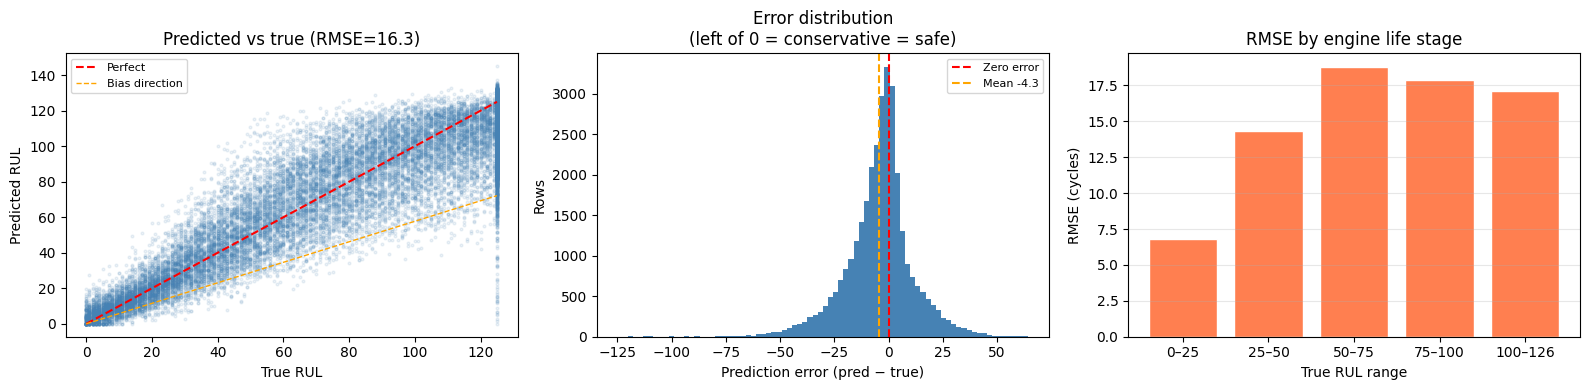

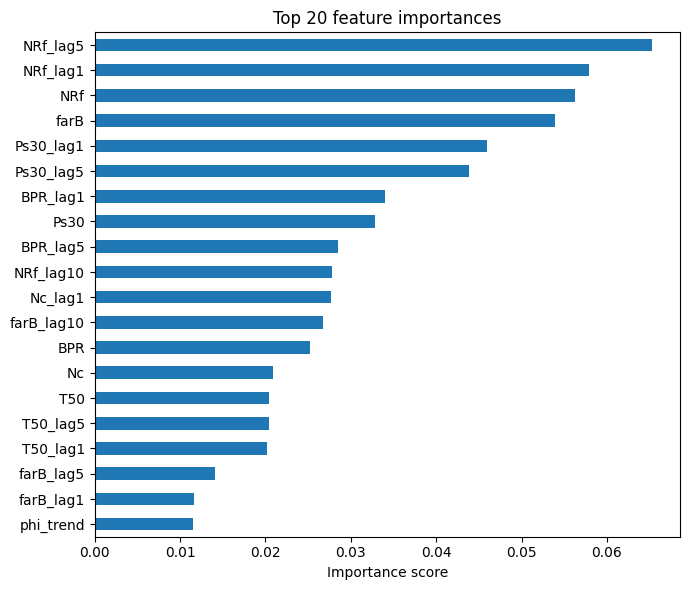

In [16]:
y_pred = reg.predict(test_df[FEATURE_COLS]).clip(0)
rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
err    = y_pred - y_test   # positive = over-predicted

print(f"Overall RMSE   : {rmse:.2f} cycles")
print(f"Mean error     : {err.mean():.2f}  (negative = conservative / safe bias)")
print(f"Std of error   : {err.std():.2f}")
print(f"90th pct error : {np.percentile(err, 90):.1f}  (worst-case over-predictions)")
print(f"10th pct error : {np.percentile(err, 10):.1f}  (worst-case under-predictions)")

# RMSE broken down by true-RUL bucket
print("\nRMSE by RUL stage:")
buckets = [(0,25,'Near failure'),(25,50,'Late'),(50,75,'Mid'),(75,100,'Early-mid'),(100,126,'Early')]
for lo, hi, label in buckets:
    mask = (y_test >= lo) & (y_test < hi)
    if mask.sum() > 0:
        r = np.sqrt(mean_squared_error(y_test[mask], y_pred[mask]))
        print(f"  RUL {lo:>3}–{hi:<3} ({label:>12}): RMSE={r:.1f}  n={mask.sum():>5}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Scatter: predicted vs true
axes[0].scatter(y_test, y_pred, alpha=0.1, s=4, color='steelblue')
axes[0].plot([0, RUL_CAP], [0, RUL_CAP], 'r--', lw=1.5, label='Perfect')
axes[0].plot([0, RUL_CAP], [0, RUL_CAP*OVERPREDICT_ALPHA**-0.5], 'orange', lw=1,
             ls='--', label='Bias direction')
axes[0].set(xlabel='True RUL', ylabel='Predicted RUL', title=f'Predicted vs true (RMSE={rmse:.1f})')
axes[0].legend(fontsize=8)

# Error histogram
axes[1].hist(err, bins=80, color='steelblue', edgecolor='none')
axes[1].axvline(0,          color='red',    ls='--', lw=1.5, label='Zero error')
axes[1].axvline(err.mean(), color='orange', ls='--', lw=1.5, label=f'Mean {err.mean():.1f}')
axes[1].set(xlabel='Prediction error (pred − true)', ylabel='Rows',
            title='Error distribution\n(left of 0 = conservative = safe)')
axes[1].legend(fontsize=8)

# RMSE by RUL bucket
labels = [f'{lo}–{hi}' for lo, hi, _ in buckets]
rmses  = []
for lo, hi, _ in buckets:
    mask = (y_test >= lo) & (y_test < hi)
    rmses.append(np.sqrt(mean_squared_error(y_test[mask], y_pred[mask])) if mask.sum() > 0 else 0)
axes[2].bar(labels, rmses, color='coral', edgecolor='white')
axes[2].set(xlabel='True RUL range', ylabel='RMSE (cycles)', title='RMSE by engine life stage')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

# Top 20 feature importances
feat_imp = pd.Series(reg.feature_importances_, index=FEATURE_COLS).nlargest(20)
fig, ax = plt.subplots(figsize=(7, 6))
feat_imp.sort_values().plot(kind='barh', ax=ax)
ax.set(title='Top 20 feature importances', xlabel='Importance score')
plt.tight_layout(); plt.show()

NASA benchmark — RUL at last observed cycle
  RMSE       : 26.40 cycles
  Mean error : -9.84  (negative = conservative bias)
  Std        : 24.49


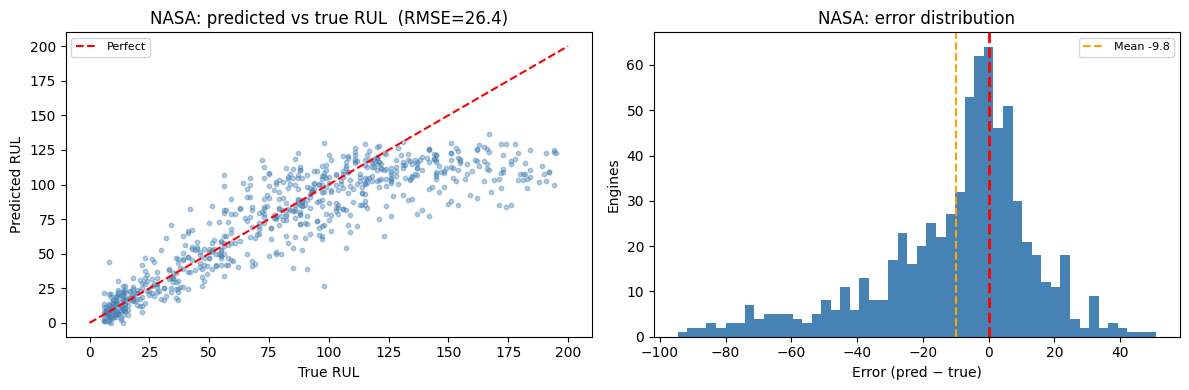

In [17]:
# NASA test set — RUL accuracy benchmark
# Each engine's last observed cycle vs true RUL (from ground truth file)
nasa_last = nasa_raw.groupby('Unit Number').last().reset_index()
nasa_last['pred_rul'] = reg.predict(nasa_last[FEATURE_COLS]).clip(0)

true_ruls = nasa_last['true_rul'].values
pred_ruls = nasa_last['pred_rul'].values
err_nasa  = pred_ruls - true_ruls
rmse_nasa = np.sqrt(mean_squared_error(true_ruls, pred_ruls))

print(f"NASA benchmark — RUL at last observed cycle")
print(f"  RMSE       : {rmse_nasa:.2f} cycles")
print(f"  Mean error : {err_nasa.mean():.2f}  (negative = conservative bias)")
print(f"  Std        : {err_nasa.std():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(true_ruls, pred_ruls, alpha=0.4, s=10, color='steelblue')
lim = max(true_ruls.max(), pred_ruls.max()) + 5
axes[0].plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect')
axes[0].set(xlabel='True RUL', ylabel='Predicted RUL', title=f'NASA: predicted vs true RUL  (RMSE={rmse_nasa:.1f})')
axes[0].legend(fontsize=8)

axes[1].hist(err_nasa, bins=50, color='steelblue', edgecolor='none')
axes[1].axvline(0,            color='red',    ls='--', lw=2)
axes[1].axvline(err_nasa.mean(), color='orange', ls='--', lw=1.5, label=f'Mean {err_nasa.mean():.1f}')
axes[1].set(xlabel='Error (pred − true)', ylabel='Engines', title='NASA: error distribution')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

=== TRIGGER sweep on held-out training engines ===

 TRIGGER  Caught (early)  Caught  Caught (late)  Missed In-time %
       5              37      43             41      21     56.3%
      10              21      81             37       3     71.8%
      15              13      89             40       0     71.8%
      20               8      92             42       0     70.4%
      25               7      99             36       0     74.6%
      30               6      86             50       0     64.8%
      40               6      84             52       0     63.4%
      50               6      79             57       0     59.9%
      75               7      75             60       0     57.7%

142 engines per row (all held-out training engines)


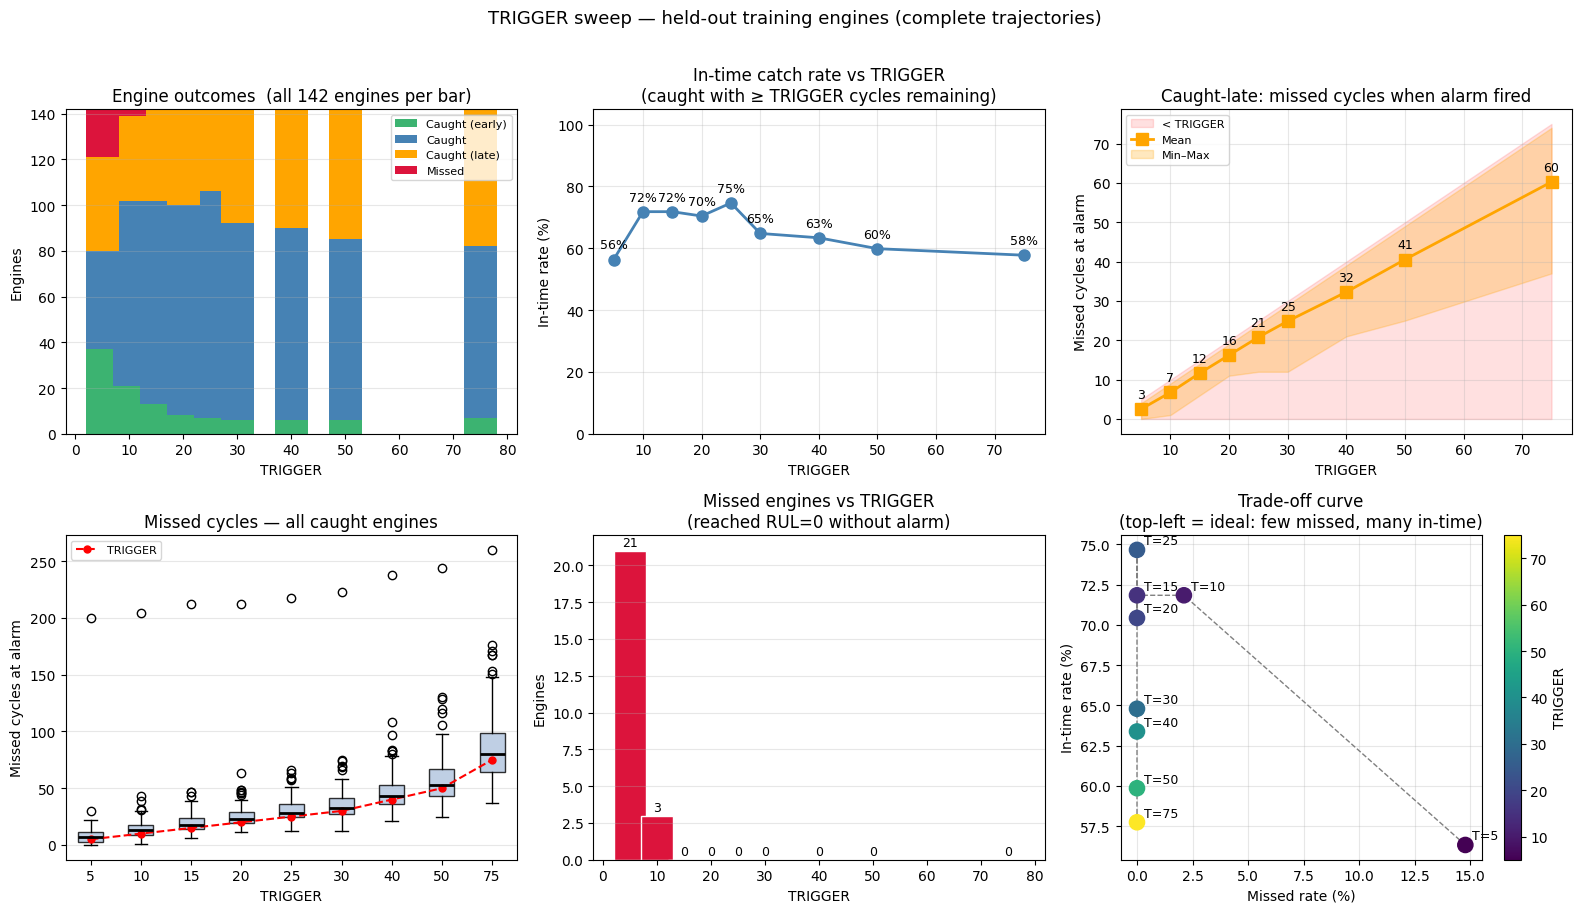

In [18]:
print("=== TRIGGER sweep on held-out training engines ===\n")
# Precompute predictions once — reused for every trigger value
test_df['pred_rul'] = reg.predict(test_df[FEATURE_COLS]).clip(0)

triggers = [5,10, 15, 20, 25, 30, 40, 50, 75]

rows = []
sw_early=[]; sw_caught=[]; sw_late=[]; sw_missed=[]
sw_intime=[]; sw_lcbf=[]; sw_ccbf=[]

for t in triggers:
    early_thresh = 2 * t
    results = []
    for unit, eng in test_df.groupby('Unit Number'):
        eng = eng.sort_values('Time (Cycles)').reset_index(drop=True)
        eligible   = eng[eng['Time (Cycles)'] >= MIN_CYCLES]
        alarm_rows = eligible[eligible['pred_rul'] < t]

        if len(alarm_rows) > 0:
            mc = max(float(alarm_rows.iloc[0]['RUL']), 0)
            if mc > early_thresh:  outcome = 'Caught (early)'
            elif mc >= t:          outcome = 'Caught'
            else:                  outcome = 'Caught (late)'
        else:
            mc      = None
            outcome = 'Missed'

        results.append({'outcome': outcome, 'missed_cycles': mc})

    df_r     = pd.DataFrame(results)
    n_total  = len(df_r)
    n_early  = (df_r['outcome'] == 'Caught (early)').sum()
    n_caught = (df_r['outcome'] == 'Caught').sum()
    n_late   = (df_r['outcome'] == 'Caught (late)').sum()
    n_missed = (df_r['outcome'] == 'Missed').sum()
    in_time  = (n_early + n_caught) / n_total

    late_cbf   = df_r.loc[df_r['outcome'] == 'Caught (late)',  'missed_cycles'].dropna().values
    caught_cbf = df_r.loc[df_r['outcome'].isin(['Caught','Caught (early)']), 'missed_cycles'].dropna().values

    sw_early.append(n_early); sw_caught.append(n_caught)
    sw_late.append(n_late);   sw_missed.append(n_missed)
    sw_intime.append(in_time * 100)
    sw_lcbf.append(late_cbf); sw_ccbf.append(caught_cbf)

    rows.append({'TRIGGER': t, 'Caught (early)': int(n_early), 'Caught': int(n_caught),
                 'Caught (late)': int(n_late), 'Missed': int(n_missed),
                 'In-time %': f'{in_time:.1%}'})

print(pd.DataFrame(rows).to_string(index=False))
print(f"\n{test_df['Unit Number'].nunique()} engines per row (all held-out training engines)")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('TRIGGER sweep — held-out training engines (complete trajectories)', fontsize=13, y=1.01)

ax = axes[0, 0]
bot1 = np.array(sw_early)
bot2 = bot1 + np.array(sw_caught)
bot3 = bot2 + np.array(sw_late)
ax.bar(triggers, sw_early,  color='mediumseagreen', width=6, label='Caught (early)')
ax.bar(triggers, sw_caught, color='steelblue',      width=6, bottom=bot1,      label='Caught')
ax.bar(triggers, sw_late,   color='orange',          width=6, bottom=list(bot2), label='Caught (late)')
ax.bar(triggers, sw_missed, color='crimson',         width=6, bottom=list(bot3), label='Missed')
ax.set(xlabel='TRIGGER', ylabel='Engines',
       title=f'Engine outcomes  (all {test_df["Unit Number"].nunique()} engines per bar)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

ax = axes[0, 1]
ax.plot(triggers, sw_intime, 'o-', color='steelblue', lw=2, ms=8)
for x, y in zip(triggers, sw_intime):
    ax.annotate(f'{y:.0f}%', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
ax.set(xlabel='TRIGGER', ylabel='In-time rate (%)',
       title='In-time catch rate vs TRIGGER\n(caught with ≥ TRIGGER cycles remaining)')
ax.set_ylim(0, 105); ax.grid(True, alpha=0.3)

ax = axes[0, 2]
late_means = [v.mean() if len(v) > 0 else 0 for v in sw_lcbf]
late_mins  = [v.min()  if len(v) > 0 else 0 for v in sw_lcbf]
late_maxs  = [v.max()  if len(v) > 0 else 0 for v in sw_lcbf]
ax.fill_between(triggers, 0, triggers, alpha=0.12, color='red', label='< TRIGGER')
ax.plot(triggers, late_means, 's-', color='orange', lw=2, ms=8, label='Mean')
ax.fill_between(triggers, late_mins, late_maxs, alpha=0.25, color='orange', label='Min–Max')
for x, y in zip(triggers, late_means):
    ax.annotate(f'{y:.0f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
ax.set(xlabel='TRIGGER', ylabel='Missed cycles at alarm', title='Caught-late: missed cycles when alarm fired')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
all_cbf = [np.concatenate([h, l]) if len(h)+len(l) > 0 else np.array([0])
           for h, l in zip(sw_ccbf, sw_lcbf)]
ax.boxplot(all_cbf, positions=range(len(triggers)), widths=0.5, patch_artist=True,
           medianprops=dict(color='black', lw=2),
           boxprops=dict(facecolor='lightsteelblue', alpha=0.8))
ax.plot(range(len(triggers)), triggers, 'r--o', ms=5, lw=1.5, label='TRIGGER')
ax.set_xticks(range(len(triggers))); ax.set_xticklabels(triggers)
ax.set(xlabel='TRIGGER', ylabel='Missed cycles at alarm', title='Missed cycles — all caught engines')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 1]
ax.bar(triggers, sw_missed, color='crimson', width=6, edgecolor='white')
for x, y in zip(triggers, sw_missed):
    ax.text(x, y + 0.3, str(y), ha='center', fontsize=9)
ax.set(xlabel='TRIGGER', ylabel='Engines', title='Missed engines vs TRIGGER\n(reached RUL=0 without alarm)')
ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 2]
missed_pct = [m / test_df['Unit Number'].nunique() * 100 for m in sw_missed]
intime_pct = sw_intime
sc = ax.scatter(missed_pct, intime_pct, c=triggers, cmap='viridis', s=120, zorder=5)
ax.plot(missed_pct, intime_pct, '--', color='gray', lw=1, zorder=4)
for x, y, t in zip(missed_pct, intime_pct, triggers):
    ax.annotate(f'T={t}', (x, y), textcoords='offset points', xytext=(5, 4), fontsize=9)
plt.colorbar(sc, ax=ax, label='TRIGGER')
ax.set(xlabel='Missed rate (%)', ylabel='In-time rate (%)',
       title='Trade-off curve\n(top-left = ideal: few missed, many in-time)')
ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## Deployment Simulation

The NASA test set cuts off before engines fail — so there is no clean "alarm never fired = failure" outcome. Instead we simulate on the **held-out training engines**: these run all the way to actual failure (RUL = 0), giving unambiguous outcomes.

For each held-out engine, step through every cycle:

1. Predict: will this engine fail within `TRIGGER` cycles?
2. **Yes** (`predicted_RUL < TRIGGER`) → stop, record **missed cycles** = true RUL at that moment
3. **No** → next cycle

**Outcomes** (every engine falls into exactly one):
- **Caught (early)**: alarm fired, `missed_cycles > 2 × TRIGGER` — very conservative
- **Caught**: alarm fired with a good buffer (`TRIGGER ≤ missed_cycles ≤ 2 × TRIGGER`)
- **Caught (late)**: alarm fired but `missed_cycles < TRIGGER` — cutting it close
- **Missed**: alarm never fired, engine reached RUL = 0 — failed without warning

Deployment simulation — 142 held-out training engines  (TRIGGER=30  MIN_CYCLES=30)
─────────────────────────────────────────────────────────────────
  Caught (early) :    6 (4.2%)   avg missed cycles = 96.2
  Caught         :   86 (60.6%)   avg missed cycles = 39.2
  Caught (late)  :   50 (35.2%)   avg missed cycles = 24.9
  Missed         :    0 (0.0%)   reached RUL=0 without alarm
─────────────────────────────────────────────────────────────────
  In-time rate   : 64.8%  (caught with ≥ TRIGGER cycles remaining)
  Any catch rate : 100.0%  (alarm fired at any point)


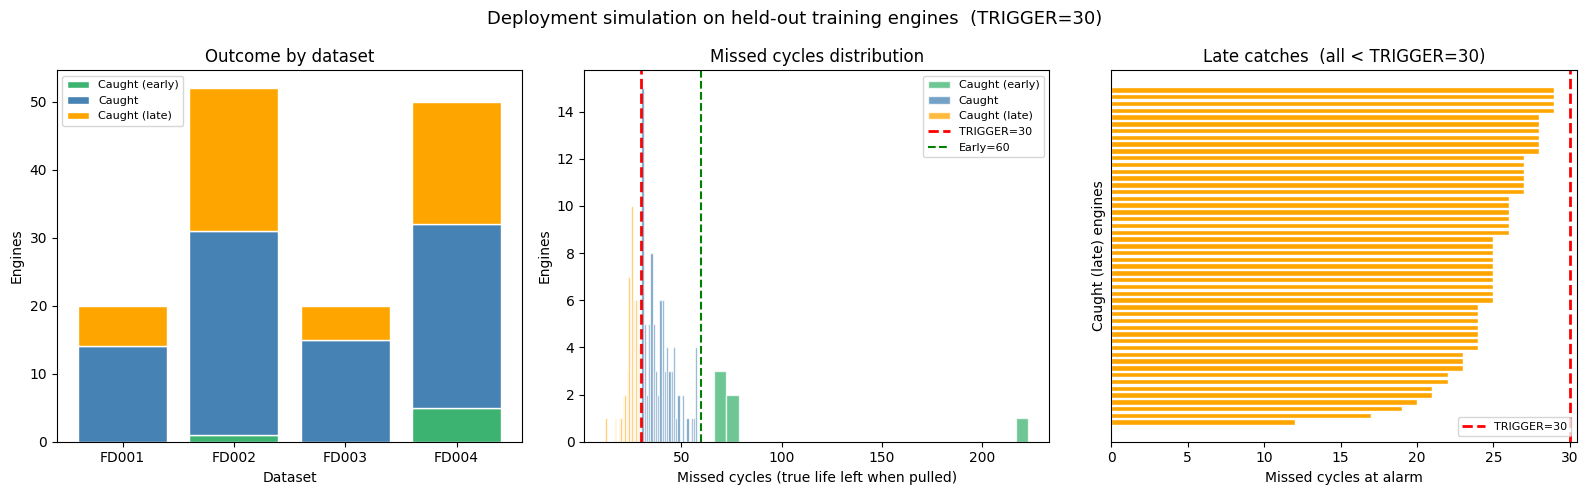

In [19]:
EARLY_THRESHOLD = 2 * TRIGGER

# ── Deployment simulation on held-out training engines ────────────────────────
# test_df['pred_rul'] already computed in the TRIGGER sweep cell above
rows = []
for unit, eng in test_df.groupby('Unit Number'):
    eng = eng.sort_values('Time (Cycles)').reset_index(drop=True)

    alarm_cycle = alarm_pred = missed_cycles = None

    for _, row in eng.iterrows():
        if row['Time (Cycles)'] < MIN_CYCLES:
            continue

        # Step 1+2: will engine break within TRIGGER cycles?
        if row['pred_rul'] < TRIGGER:
            alarm_cycle   = row['Time (Cycles)']
            alarm_pred    = row['pred_rul']
            missed_cycles = max(float(row['RUL']), 0)
            break
        # Step 3: no → check next cycle

    if alarm_cycle is not None:
        if missed_cycles > EARLY_THRESHOLD:  outcome = 'Caught (early)'
        elif missed_cycles >= TRIGGER:        outcome = 'Caught'
        else:                                 outcome = 'Caught (late)'
    else:
        outcome = 'Missed'

    rows.append({
        'Engine':         unit,
        'Dataset':        eng['dataset'].iloc[0],
        'Alarm at cycle': int(alarm_cycle) if alarm_cycle else None,
        'Pred RUL':       round(alarm_pred, 1) if alarm_pred is not None else None,
        'Missed cycles':  round(missed_cycles, 1) if missed_cycles is not None else None,
        'Outcome':        outcome,
    })

sim = pd.DataFrame(rows)

# ── Summary ───────────────────────────────────────────────────────────────────
early  = sim[sim['Outcome'] == 'Caught (early)']
caught = sim[sim['Outcome'] == 'Caught']
late   = sim[sim['Outcome'] == 'Caught (late)']
missed = sim[sim['Outcome'] == 'Missed']

n = len(sim)
print(f"Deployment simulation — {n} held-out training engines  (TRIGGER={TRIGGER}  MIN_CYCLES={MIN_CYCLES})")
print(f"{'─'*65}")
print(f"  Caught (early) : {len(early):>4} ({len(early)/n:.1%})   avg missed cycles = {early['Missed cycles'].mean():.1f}")
print(f"  Caught         : {len(caught):>4} ({len(caught)/n:.1%})   avg missed cycles = {caught['Missed cycles'].mean():.1f}")
print(f"  Caught (late)  : {len(late):>4} ({len(late)/n:.1%})   avg missed cycles = {late['Missed cycles'].mean():.1f}")
print(f"  Missed         : {len(missed):>4} ({len(missed)/n:.1%})   reached RUL=0 without alarm")
print(f"{'─'*65}")
print(f"  In-time rate   : {(len(early)+len(caught))/n:.1%}  (caught with ≥ TRIGGER cycles remaining)")
print(f"  Any catch rate : {(n-len(missed))/n:.1%}  (alarm fired at any point)")

if len(missed) > 0:
    print(f"\nMissed engines:")
    print(missed[['Engine','Dataset']].to_string(index=False))

# ── Plots ─────────────────────────────────────────────────────────────────────
outcome_order = ['Caught (early)', 'Caught', 'Caught (late)', 'Missed']
colors        = ['mediumseagreen', 'steelblue', 'orange', 'crimson']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Deployment simulation on held-out training engines  (TRIGGER={TRIGGER})', fontsize=13)

datasets = sorted(sim['Dataset'].unique())
bottom = np.zeros(len(datasets))
for outcome, color in zip(outcome_order, colors):
    counts = [sim[(sim['Dataset']==d) & (sim['Outcome']==outcome)].shape[0] for d in datasets]
    if sum(counts) > 0:
        axes[0].bar(datasets, counts, bottom=bottom, color=color, label=outcome, edgecolor='white')
        bottom += np.array(counts)
axes[0].set(xlabel='Dataset', ylabel='Engines', title='Outcome by dataset')
axes[0].legend(fontsize=8)

for outcome, color in zip(['Caught (early)', 'Caught', 'Caught (late)'],
                           ['mediumseagreen', 'steelblue', 'orange']):
    subset = sim[sim['Outcome'] == outcome]['Missed cycles'].dropna()
    if len(subset) > 0:
        axes[1].hist(subset, bins=25, color=color, edgecolor='white', alpha=0.75, label=outcome)
axes[1].axvline(TRIGGER,         color='red',   ls='--', lw=2,   label=f'TRIGGER={TRIGGER}')
axes[1].axvline(EARLY_THRESHOLD, color='green', ls='--', lw=1.5, label=f'Early={EARLY_THRESHOLD}')
axes[1].set(xlabel='Missed cycles (true life left when pulled)',
            ylabel='Engines', title='Missed cycles distribution')
axes[1].legend(fontsize=8)

if len(late) > 0:
    axes[2].barh(range(len(late)),
                 late.sort_values('Missed cycles')['Missed cycles'].values,
                 color='orange', edgecolor='white')
    axes[2].axvline(TRIGGER, color='red', ls='--', lw=2, label=f'TRIGGER={TRIGGER}')
    axes[2].set(xlabel='Missed cycles at alarm',
                ylabel='Caught (late) engines',
                title=f'Late catches  (all < TRIGGER={TRIGGER})')
    axes[2].legend(fontsize=8); axes[2].set_yticks([])

plt.tight_layout(); plt.show()

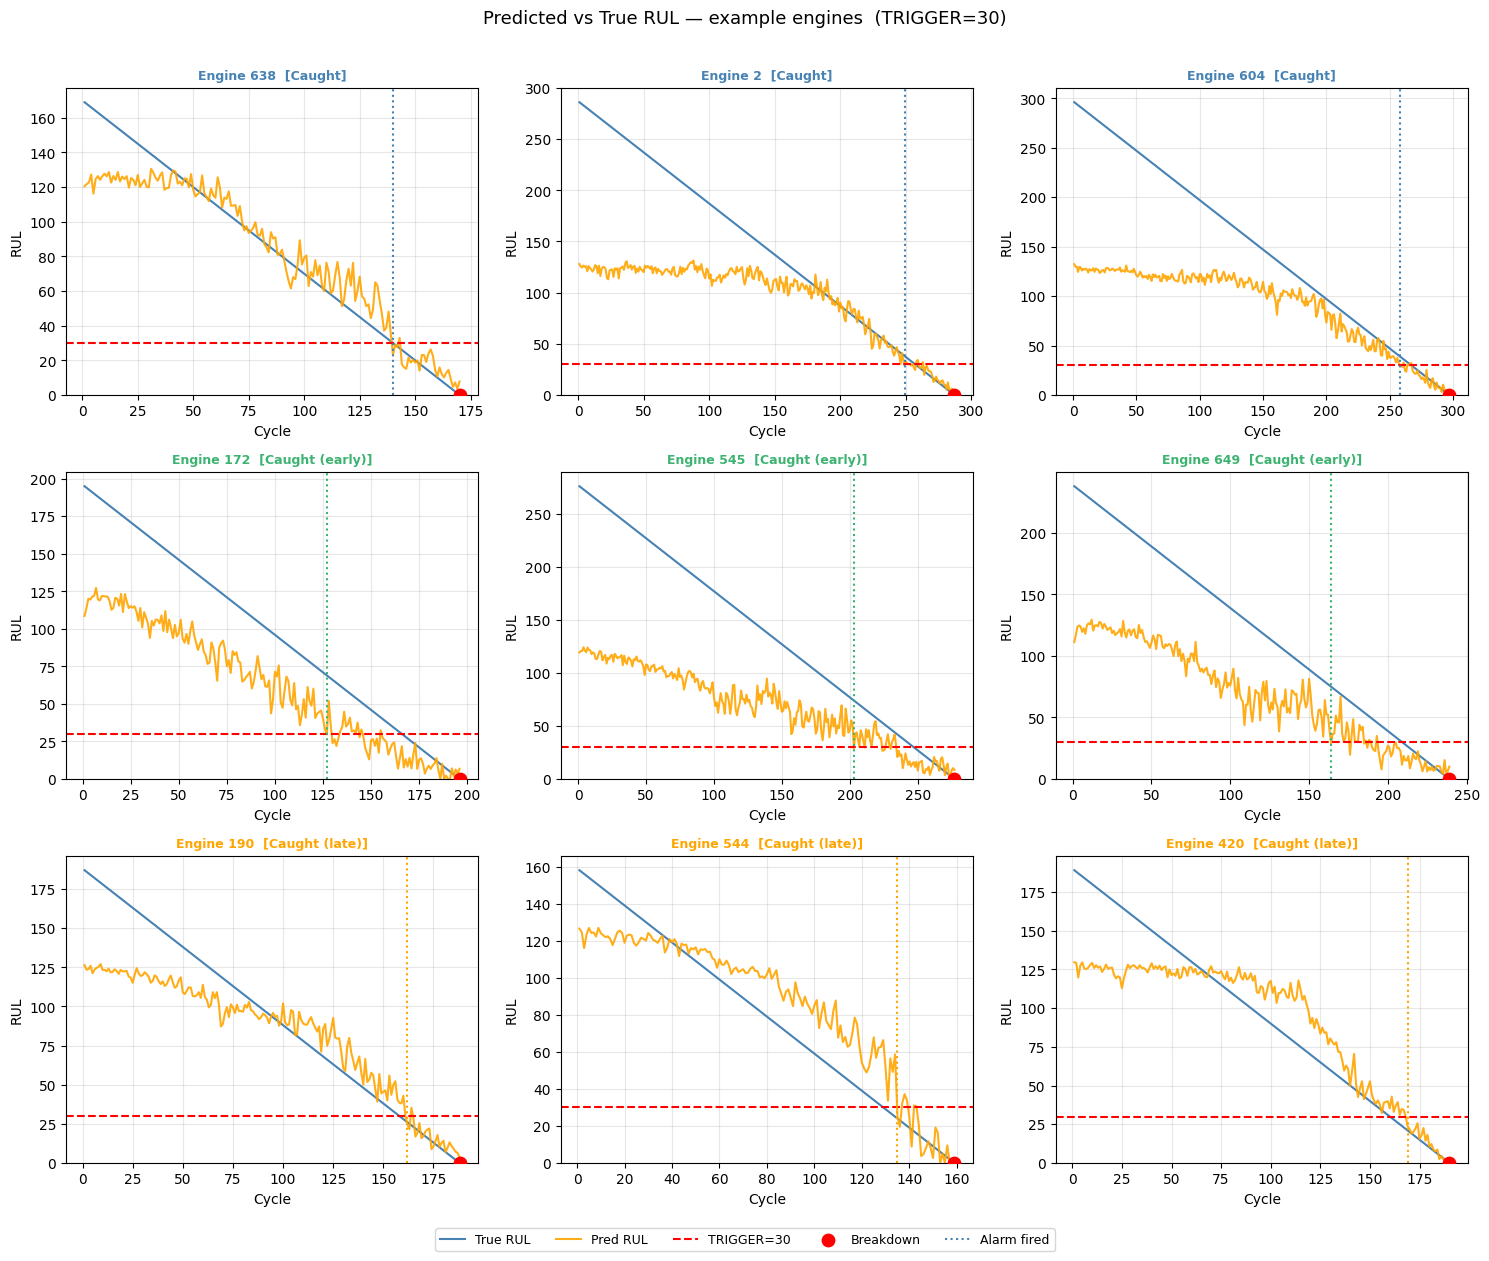

In [20]:
# ── Predicted vs True RUL — sample engines ───────────────────────────────────
sample_units = []
for outcome in sorted(sim['Outcome'].unique()):
    units = sim.loc[sim['Outcome'] == outcome, 'Engine'] \
               .sample(min((sim['Outcome'] == outcome).sum(), 3), random_state=42) \
               .tolist()
    sample_units.extend(units)

n = len(sample_units)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
fig.suptitle(f'Predicted vs True RUL — example engines  (TRIGGER={TRIGGER})', fontsize=13, y=1.01)
axes_flat = list(axes.flat)

outcome_colors = {
    'Caught (early)': 'mediumseagreen',
    'Caught':         'steelblue',
    'Caught (late)':  'orange',
    'Missed':         'crimson',
}

for ax, unit in zip(axes_flat, sample_units):
    eng      = test_df[test_df['Unit Number'] == unit].sort_values('Time (Cycles)')
    cycles   = eng['Time (Cycles)'].values
    true_rul = eng['RUL'].values
    pred_rul = eng['pred_rul'].values

    outcome = sim.loc[sim['Engine'] == unit, 'Outcome'].values[0]
    color   = outcome_colors[outcome]

    ax.plot(cycles, true_rul, color='steelblue', lw=1.5, label='True RUL')
    ax.plot(cycles, pred_rul, color='orange',    lw=1.5, label='Pred RUL', alpha=0.9)
    ax.axhline(TRIGGER, color='red', ls='--', lw=1.5, label=f'TRIGGER={TRIGGER}')

    # Last cycle — engine breakdown
    ax.scatter(cycles[-1], true_rul[-1], color='red', zorder=5, s=80, label='Breakdown')

    # Mark alarm cycle if caught
    alarm_cycle = sim.loc[sim['Engine'] == unit, 'Alarm at cycle'].values[0]
    if pd.notna(alarm_cycle):
        ax.axvline(alarm_cycle, color=color, ls=':', lw=1.5, label='Alarm fired')

    ax.set_title(f'Engine {unit}  [{outcome}]', fontsize=9, color=color, fontweight='bold')
    ax.set(xlabel='Cycle', ylabel='RUL')
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)

for ax in axes_flat[n:]:
    ax.set_visible(False)

handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout()
plt.show()

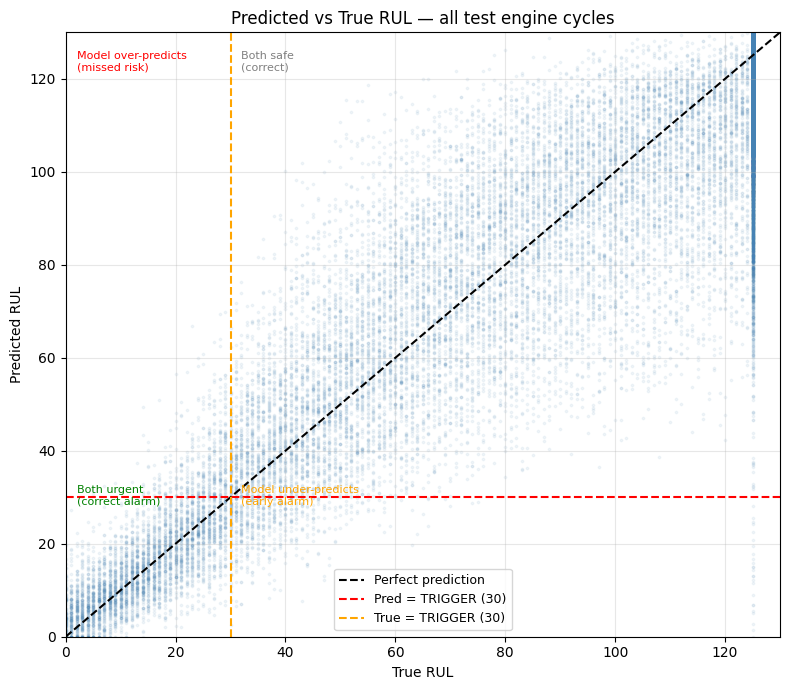

In [21]:
# ── Scatter: predicted vs true RUL — all test_df cycles ──────────────────────
true_all = test_df['RUL'].clip(upper=RUL_CAP).values
pred_all = test_df['pred_rul'].values
lim = RUL_CAP + 5

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(true_all, pred_all, alpha=0.07, s=3, color='steelblue')

ax.plot([0, lim], [0, lim], 'k--', lw=1.5, label='Perfect prediction')
ax.axhline(TRIGGER, color='red',    ls='--', lw=1.5, label=f'Pred = TRIGGER ({TRIGGER})')
ax.axvline(TRIGGER, color='orange', ls='--', lw=1.5, label=f'True = TRIGGER ({TRIGGER})')

# Quadrant labels
ax.text(2,          lim - 4,  'Model over-predicts\n(missed risk)',  fontsize=8, color='red',    va='top')
ax.text(TRIGGER+2,  lim - 4,  'Both safe\n(correct)',                fontsize=8, color='gray',   va='top')
ax.text(2,          TRIGGER-2,'Both urgent\n(correct alarm)',         fontsize=8, color='green',  va='bottom')
ax.text(TRIGGER+2,  TRIGGER-2,'Model under-predicts\n(early alarm)',  fontsize=8, color='orange', va='bottom')

ax.set(xlabel='True RUL', ylabel='Predicted RUL',
       title='Predicted vs True RUL — all test engine cycles',
       xlim=(0, lim), ylim=(0, lim))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()